In [226]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import random


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);
import PENN_exp_log
importlib.reload(PENN_exp_log);

In [227]:
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 3600           # number of time steps
DT = T_HORIZON / (T - 1)   # 3.6036s — fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [228]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cnr': 'R-averaged negative particle concentration [mol.m-3]',
    'cpr': 'R-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'cnr','cpr']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = {}
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols, t_fixed=t_fixed):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols, t_fixed=t_fixed):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols,t_fixed=t_fixed):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0):
    '''Generate trajectories with shape (B, T, D, R) for cnr/cpr and (B, T, D) for scalars'''

    # spatial points in cnr/cpr

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cnr','cpr']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)
      # keep R for all variables, scalars will be broadcast
    var_index = {k: i for i, k in enumerate(all_cols)}

    for b in trange(B):

        # --- generate data ---
        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(random.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")


        R = data['cnr'].shape[0] if 'cnr' in data_cols else 1  # number of spatial points, default to 1 for scalars 
        X = np.zeros((B, T, D, R))
        # --- assign base variables ---
        for col in data_cols:
            x = data[col]  # shape (T,) for scalars, (R, T) for cnr/cpr
            if x.ndim == 1:
                X[b, :, var_index[col], :] = np.tile(x[:, None], (1, R))
            else:
                X[b, :, var_index[col], :] = x.T  # (R, T) -> (T, R)

        # --- compute dI ---
        if 'I' in data_cols:
            I = data['I']
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI'], :] = np.tile(dI[:, None], (1, R))

        # --- compute derivatives ---
        for col in ['cnr', 'cpr']:
            if col in data_cols:
                x = data[col]  # (R, T)
                xdot = np.zeros_like(x)
                xdot[:, :-1] = np.diff(x, axis=1) / DT
                xdot[:, -1] = xdot[:, -2]
                X[b, :, var_index[f"{col}_dot"], :] = xdot.T

        # --- valid mask ---
        X[b, :, var_index['valid'], :] = np.tile(valid_b[:, None], (1, R))

    return X, var_index,param

In [229]:
currents = 'DC'
dot_cols = [f"{k}_dot" for k in data_cols if k in ['cnr','cpr']]
all_cols = data_cols + ['dI'] + dot_cols + ['valid']
X, var_index, params = gen_data(2, data_cols, currents=currents, I_low=0.25, I_high=1.0)
print("Data shape:", X.shape)
print("Variable index:", var_index)


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:06<00:00,  3.26s/it]

Data shape: (2, 3600, 8, 20)
Variable index: {'I': 0, 'V': 1, 'cnr': 2, 'cpr': 3, 'dI': 4, 'cnr_dot': 5, 'cpr_dot': 6, 'valid': 7}


In [230]:
# currents = 'DC'
# B_gen = 500

# print(f'Generating {B_gen} batches of {currents} profiles with length {T} and variables {all_cols}')

# dataX, var_index,params  = gen_data(B_gen, data_cols, currents=f'{currents}', I_low=0.25, I_high=1.0)
# dataX = dataX.astype(np.float32)
# np.savez_compressed(f'data_cx/B{B_gen}_data_cx_{currents}_dt_{T}.npz', X=dataX, var_index=var_index)


In [231]:
# --- Load data ---
def load_data(path, var_index):
    """Load 4D data (B, T, D, R) and return dict of arrays."""
    with np.load(path) as d:
        X = d['X']  # or your actual key

    data = {}
    for var, idx in var_index.items():
        # keep last axis for spatial variables
        data[var] = X[:, :, idx, :]  # shape (B, T, R)

        # optional: collapse R for scalars (I, V, etc.)
        if var in ['I', 'V', 'dI', 'valid']:
            data[var] = data[var][:, :, 0]  # shape (B, T)

    return data


path = f'data_cx/B2_data_cx_{currents}_dt_{T}.npz'
D = load_data(path,var_index)

I = D['I']; V = D['V']; cnr = D['cnr']; cpr = D['cpr']; cnr_dot = D['cnr_dot'];cpr_dot=D['cpr_dot']; valid = D['valid']


B = I.shape[0]

D['valid'] = D['valid'].astype(bool)


print("Loaded data shapes:")
for key, value in D.items():
    print(f"{key}: \t{value.shape}")


Loaded data shapes:
I: 	(2, 3600)
V: 	(2, 3600)
cnr: 	(2, 3600, 20)
cpr: 	(2, 3600, 20)
dI: 	(2, 3600)
cnr_dot: 	(2, 3600, 20)
cpr_dot: 	(2, 3600, 20)
valid: 	(2, 3600)


## Exploring data

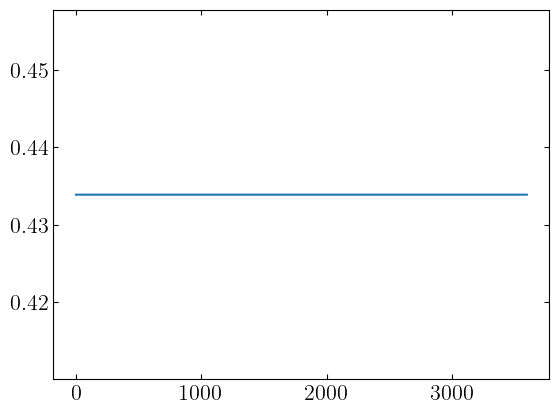

In [232]:
plt.plot(D['I'][1])

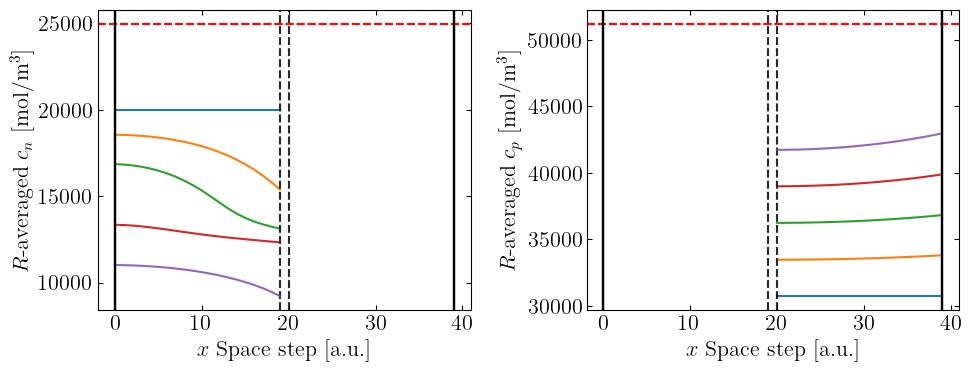

In [233]:
n = len(cnr[0,0,:])

f, ax = plt.subplots(1, 2, figsize=(10, 4))
for times in np.linspace(0, len(t_fixed)-1, 5):
    electrode = ['n', 'p']
    x = np.arange(0,2*n)
    xn = np.arange(0, n)
    xp = x[-1] - np.arange(0, n)
    ax[0].plot(xn, cnr[1,int(times),:])
    ax[0].axhline(params['Maximum concentration in negative electrode [mol.m-3]'], color='r', linestyle='--', alpha=0.5)
    ax[1].plot(xp, cpr[1,int(times),:])
    ax[1].axhline(params['Maximum concentration in positive electrode [mol.m-3]'], color='r', linestyle='--', alpha=0.5)
    for i,a in enumerate(ax):
        a.axvline(0, color = 'k')
        a.axvline(x[-1], color ='k')
        a.axvline(xn[-1], color = 'k', linestyle='--',alpha=0.3)
        a.axvline(xp[-1], color = 'k', linestyle='--',alpha=0.3)
        a.set_xlabel('$x$ Space step [a.u.]')
        a.set_ylabel(f'$R$-averaged $c_{electrode[i]}$ [mol$/$m$^3$]')
plt.tight_layout()

In [234]:

# def fit():
#     for name, arr in zip(['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot'], 
#                          [I, dI, V, cn, cn_dot, cp, cp_dot]):
#         stats[name] = (float(arr.mean()), float(max(arr.std(), 1e-8)))  # Avoid zero std
#     return stats
stats = {}
def compute_stats(D=D, data_cols=all_cols):
    stats = {}
    for name in data_cols:
        arr = D[name]  # (B,T) or (B,T,R)
        valid = D['valid']  # (B,T)
        
        if arr.ndim == 3:
            # repeat valid along last axis
            mask = np.repeat(valid[:, :, None], arr.shape[2], axis=2)
        else:
            mask = valid

        vals = arr[mask]  # flatten automatically to 1D
        mean = float(vals.mean())
        std = float(max(vals.std(), 1e-8))
        stats[name] = (mean, std)
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize
I_n = transform(I, "I")
cn_n = transform(cnr, "cnr")
cp_n = transform(cpr, "cpr")
cn_dot_n = transform(cnr_dot, "cnr_dot")
cp_dot_n = transform(cpr_dot, "cpr_dot")

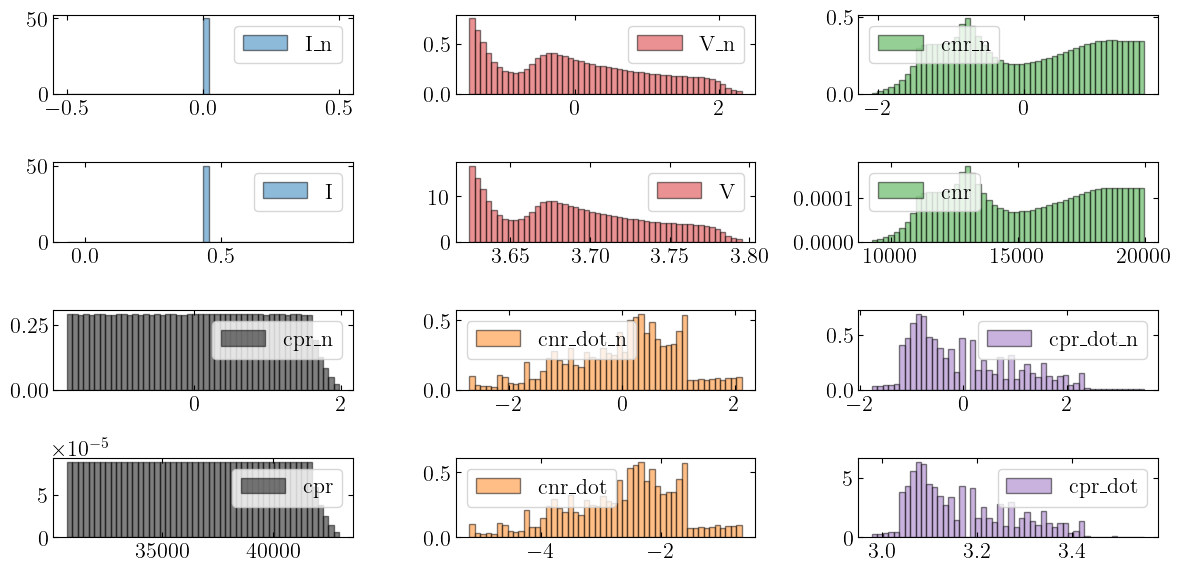

In [235]:
import math

def get_valid_mask(arr, valid):
    """
    Return a mask of the same shape as arr, using valid mask.
    Works for both 2D (B,T) and 3D (B,T,R) arrays.
    """
    if arr.ndim == 2:
        return valid
    elif arr.ndim == 3:
        # repeat along last axis
        return np.repeat(valid[:, :, None], arr.shape[2], axis=2)
    else:
        raise ValueError(f"Unsupported array shape: {arr.shape}")


def plot_histograms(D, vars_to_plot, transform_func=transform, bins=50, alpha=0.5, plot_colors=None):
    n_vars = len(vars_to_plot)
    n_cols = min(3, n_vars)
    n_rows =  2 * math.ceil(n_vars / n_cols)

    if plot_colors is None:
        plot_colors = ['tab:blue', 'tab:red', 'tab:green', 'black', 'tab:orange', 'tab:purple']

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*math.ceil(n_vars/3)))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for idx, var in enumerate(vars_to_plot):
        col_idx = idx % n_cols
        row_block = (idx // n_cols) * 2

        # normalized
        ax = axes[row_block, col_idx]
        arr_n = transform_func(D[var], var)
        mask_n = get_valid_mask(arr_n, D['valid'])
        vals_n = arr_n[mask_n]
        ax.hist(vals_n, bins=bins, alpha=alpha, color=plot_colors[idx % len(plot_colors)],
               edgecolor='black', label=f'{var}_n',density = True)
        ax.legend()

        # original
        ax = axes[row_block + 1, col_idx]
        arr = D[var]
        mask = get_valid_mask(arr, D['valid'])
        vals = arr[mask]
        ax.hist(vals, bins=bins, alpha=alpha, color=plot_colors[idx % len(plot_colors)],
                edgecolor='black', label=f'{var}', density = True)
        ax.legend()

    # hide empty subplots
    for r in range(n_rows):
        for c in range(n_cols):
            flat_idx = r//2 * n_cols + c
            if flat_idx >= n_vars:
                axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

plot_histograms(D, ['I', 'V', 'cnr', 'cpr', 'cnr_dot', 'cpr_dot'], transform_func=transform, bins=50)


In [236]:
I_exp = I_n[..., None]            # shape (B, T, 1)
x_np = np.concatenate([I_exp, cn_n, cp_n], axis=-1)  # shape (B, T, 1+R+R = 1+2R)
x = torch.tensor(x_np, dtype=torch.float32) # [B, T, 1+2R]
y = torch.tensor(np.concatenate([cn_dot_n, cp_dot_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(valid, dtype=torch.float32)

print(x.shape, y.shape, mask.shape)


torch.Size([2, 3600, 41]) torch.Size([2, 3600, 40]) torch.Size([2, 3600])


In [239]:

# Flatten time dimension for training
B, T, C = x.shape
_,_, Tar = y.shape

# Split
split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)


x_train, x_test = _split_flat(x)
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

cnr_train, cnr_test = _split(cnr)
cpr_train, cpr_test = _split(cpr)
cnr_dot_train, cnr_dot_test = _split(cnr_dot)
cpr_dot_train, cpr_dot_test = _split(cpr_dot)
I_train, I_test = _split(I)

# x_train_batch, x_test_batch = x[:split], x[split:]
# y_train_batch, y_test_batch = y[:split], y[split:]
# mask_train_batch, mask_test_batch = mask[:split], mask[split:]


# Un-normalized for plotting
# cn_test = cn[split:]
# cp_test = cp[split:]
# cn_dot_test = cn_dot[split:]
# cp_dot_test = cp_dot[split:]
# I_test = I[split:]
# dI_test = dI[split:]
# mask_test_plot = valid[split:]

# V_test = V[split:]

# cn_train = cn[:split]
# cp_train = cp[:split]
# cn_dot_train = cn_dot[:split]
# cp_dot_train = cp_dot[:split]
# I_train = I[:split]
# dI_train = dI[:split]
# mask_train_plot = valid[:split]

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape)


#batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
#train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

Shapes: torch.Size([3600, 41]) torch.Size([3600, 40]) torch.Size([3600])


In [161]:

# dc_dI = np.gradient(cn_test[0, :].ravel(), I_test[0, :].ravel())  # Numerical gradient w.r.t. I

# dc_dI = cn_dot_test[0, :] / (dI_test[0, :] + 1e-8)  # Add small epsilon to avoid division by zero

# fig, axes = plt.subplots(1, 4, figsize=(15, 3))
# axes[0].plot(cn_test[0, :], label='cn')
# axes[1].plot(cn_dot_test[0, :], label='valid')
# axes[2].plot(dI_n[0, :], label='dI')
# # axes[3].plot(dc_dI, label='cdot')

# dI_n[0, :].mean()

In [ ]:
''' Mk 1 '''
class Net(nn.Module):
    def __init__(self, input_size=41, hidden_size=256):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 40)   # [cn_dot, cp_dot]
        )
    
    # def forward(self, x):
    #     x = self.net(x)
    #     return x
    def forward(self, input, params=params, PE = True):
        if PE:
            out = self.net(input)

            X_len = int(out.shape[1] / 2)

            cn_raw = inverse_transform(out[:, :X_len],"cnr_dot")
            cp_raw = inverse_transform(out[:, X_len:],'cpr_dot')
            Ln = params['Negative electrode thickness [m]']
            Lp = params['Positive electrode thickness [m]']
            A = params['Electrode height [m]'] * params['Electrode width [m]']
            fvn = params['Negative electrode active material volume fraction']
            fvp = params['Positive electrode active material volume fraction']
            n = cn_raw.shape[1]
            dxn = Ln / n
            dxp = Lp / n
            kp = dxp * fvp * A
            kn = dxn * fvn * A
            # Compute physical quantities
            sn = (cn_raw * kn).sum(dim=1, keepdim=True)
            sp = (cp_raw * kp).sum(dim=1, keepdim=True)

            s = (sp + sn) / (n *kp + n * kn)
            

            cn = cn_raw - s
            cp = cp_raw - s
            cn = transform(cn, "cnr_dot")
            cp = transform(cp, "cpr_dot")


            return torch.cat([cn, cp], dim=1)
        else:
            return self.net(input)
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
summary(model, input_data=x_train[:2])

In [163]:
def masked_mse(pred, target, mask):
    # pred, target: (N, 2)   mask: (N)
    err = (pred - target) ** 2    # (B*T, 2)
    m = mask.unsqueeze(-1)        # (B*T, 1) — broadcasts over 2 outputs
    return (err * m).sum() / (m.sum() * 2)

''' Mk 1: Standard training '''
def training(epochs=30, PE = True):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        p_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            pred = model(x_b)   # [B*T, 2]
            d_loss = masked_mse(pred, y_b, mask_b)
            p_loss = 0
            tot_loss = d_loss + p_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item() + p_loss
            d_ep_loss += d_loss.item()
            p_ep_loss += p_loss

        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        p_last = p_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | d_loss {d_last:.3e} | time {end_t - start_t:.2f}s")

    return history

''' Mk 2: Distinguish dI peaks and apply loss only there '''
# def training(epochs=30):
#     history = {"loss": []}
#     for ep in range(epochs):
#         model.train()
#         ep_loss = 0.0

#         for x_b, y_b, mask_b in train_loader_flat:
#             # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
#             pred = model(x_b)   # [B*T, 2]
#             loss = masked_mse(pred, y_b, mask_b)
            
#             for i, dI in enumerate(x_b[:, 1]):  # Assuming dI is the second feature
#                 if dI != -0.013627593405544758 and dI > 0:
#                     for t in range(np.arange(0, 100, 10)):  # Example: only consider every 10th time step
#                         mask_b_new = mask_b.clone()
#                         mask_b_new[t] = 1.0  # Set the mask for this specific time step to 1 (i.e., include in loss)
#                         loss = masked_mse(pred, cn_positive, mask_b_new)  # Or some custom loss that emphasizes this point
#                         print(dI.item(), i)

#             # print('pred shapes:', pred.shape)
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
#             ep_loss += loss.item()

#         last = ep_loss / len(train_loader_flat)  # Average loss per batch
#         history["loss"].append(last)
#         print(f"Epoch {ep+1} | loss {last:.3e}")

#     return history

history = training(epochs=100, PE = True)

ETA: 7.36 min
Epoch 1 | loss 1.913e+01 | d_loss 1.913e+01 | time 4.42s
Epoch 2 | loss 1.610e+01 | d_loss 1.610e+01 | time 3.87s
Epoch 3 | loss 1.416e+01 | d_loss 1.416e+01 | time 3.66s
Epoch 4 | loss 1.166e+01 | d_loss 1.166e+01 | time 3.48s
Epoch 5 | loss 8.562e+00 | d_loss 8.562e+00 | time 3.09s
Epoch 6 | loss 5.768e+00 | d_loss 5.768e+00 | time 3.42s
Epoch 7 | loss 4.661e+00 | d_loss 4.661e+00 | time 3.25s
Epoch 8 | loss 4.349e+00 | d_loss 4.349e+00 | time 3.34s
Epoch 9 | loss 3.754e+00 | d_loss 3.754e+00 | time 3.07s
Epoch 10 | loss 3.397e+00 | d_loss 3.397e+00 | time 3.32s
Epoch 11 | loss 3.205e+00 | d_loss 3.205e+00 | time 3.14s
Epoch 12 | loss 2.978e+00 | d_loss 2.978e+00 | time 3.33s
Epoch 13 | loss 2.726e+00 | d_loss 2.726e+00 | time 3.17s
Epoch 14 | loss 2.510e+00 | d_loss 2.510e+00 | time 3.30s
Epoch 15 | loss 2.312e+00 | d_loss 2.312e+00 | time 3.35s
Epoch 16 | loss 2.088e+00 | d_loss 2.088e+00 | time 3.16s
Epoch 17 | loss 1.875e+00 | d_loss 1.875e+00 | time 3.51s
Epoch 18 

In [164]:
model_name = 'Second_PENN_ReLU'
PENN_exp_log.exp_log(model, history, current = currents,name=model_name, d_loss_type = 'mse')

In [165]:
# save trained model
torch.save(model.state_dict(), f'models/{model_name}_{currents}.pth')

0.19727419316768646


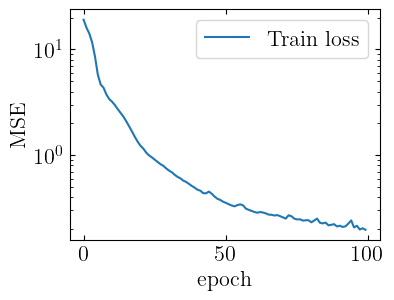

In [166]:
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

In [167]:
# def rollout(idx=0, on_train=False, cnr_dot_train = cnr_dot_train, cnr_dot_test = cnr_dot_test, cpr_dot_train = cpr_dot_train, cpr_dot_test = cpr_dot_test,
#         cn_train = cnr_train, cn_test = cnr_test, cp_train = cpr_train, cp_test = cpr_test, I_train = I_train, I_test = I_test, params = params):
    
#     if on_train:
#         cn_true = cn_train
#         cp_true = cp_train
#         I_true = I_train
#     else:
#         cn_true = cn_test
#         cp_true = cp_test
#         I_true = I_test

#     model.eval()

#     # Initial un-normalized values for the chosen trajectory
#     c0_n = cn_true[idx, 0, :]
#     c0_p = cp_true[idx, 0, :]

#     cn_min = cn_true[idx].min()  # For explicit stopper criterion

#     x_len = cn_true.shape[2]  # R spatial points
#     cn_traj = np.zeros((T,x_len), dtype=np.float32)
#     cp_traj = np.zeros((T,x_len), dtype=np.float32)
#     cn_dot_traj = np.zeros((T,x_len), dtype=np.float32)
#     cp_dot_traj = np.zeros((T,x_len), dtype=np.float32)
#     cn_traj[0,...] = c0_n
#     cp_traj[0,...] = c0_p

#     steps_run = 1

#     with torch.no_grad():
#         for t in range(T - 1):
#             # build normalised input for this step
#             I_val  = np.array([float(I_true[idx, t])])

#             cn_traj_n = transform(cn_traj[t,:], "cnr")  # shape (T, R)
#             cp_traj_n = transform(cp_traj[t,:], "cpr")  # shape (T, R) 
#             I_val_n = transform(I_val, "I")         # shape (1,)

#             x_np = np.concatenate([I_val_n, cn_traj_n, cp_traj_n], axis=-1)
#             x_t = torch.tensor(x_np, dtype=torch.float32)  # shape (1, 1, 1+2R)
#             # x_t = np.array([[
#             #     transform(np.array([[[I_val]]]),  "I")[0,0,0],  # True
#             #     transform(np.array([[[cn_traj[t,:]]]]), "cnr")[0,0,0],     # Predicted
#             #     transform(np.array([[[cp_traj[t,:]]]]), "cpr")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)
#             # print('Input x_t shape:', x_t.shape)
#             # Predict on initial state (1, 4)
#             pred = model(torch.tensor(x_t))              # (1, 2)
#             dc_n = inverse_transform(pred[20:].numpy(), "cnr_dot")
#             dc_p = inverse_transform(pred[-20:].numpy(), "cpr_dot")

#             cn_traj[t+1] = cn_traj[t] + dc_n * DT
#             cp_traj[t+1] = cp_traj[t] + dc_p * DT
#             cn_dot_traj[t] = dc_n
#             cp_dot_traj[t] = dc_p

#             steps_run += 1

#             # #Stop if concentration goes below a threshold
#             # if cn_traj[t+1,:] < cn_min:  # Depleated battery
#             #    break

#     return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run


def rollout(idx=0, on_train=False,dt = DT, cnr_train = cnr_train, cnr_test = cnr_test, cpr_train = cpr_train, cpr_test = cpr_test,
        I_train = I_train, I_test = I_test, params = params):

    if on_train:
        cn_true, cp_true, I_true = cnr_train, cpr_train, I_train
    else:
        cn_true, cp_true, I_true = cnr_test, cpr_test, I_test

    model.eval()

    c0_n = cn_true[idx, 0, :]   # (R,)
    c0_p = cp_true[idx, 0, :]

    x_len = cn_true.shape[2]  # R

    t_data = np.arange(T) * DT   # Original time points of the data (1000,)
    max_steps = int(T_HORIZON / dt)    

    cn_traj = np.zeros((max_steps, x_len), dtype=np.float32)
    cp_traj = np.zeros((max_steps, x_len), dtype=np.float32)
    cn_dot_traj = np.zeros((max_steps, x_len), dtype=np.float32)
    cp_dot_traj = np.zeros((max_steps, x_len), dtype=np.float32)

    cn_traj[0] = c0_n
    cp_traj[0] = c0_p

    I_np   = I_true.detach().numpy()   if isinstance(I_true, torch.Tensor) else I_true
    #cn_np = cn_true.detach().numpy() if isinstance(cn_true, torch.Tensor) else cn_true
    #cp_np = cp_true.detach().numpy() if isinstance(cp_true, torch.Tensor) else cp_true


    with torch.no_grad():
        for step in range(max_steps-1):
            t = step * dt
            # --- Build input ---

            I_t_np   = np.array([float(np.interp(t, t_data, I_np[idx]))])  # Interpolate I at time t for trajectory idx
            #cn_t_np = np.interp(t, t_data, cn_np[idx], axis=0)  # Interpolate cn at time t for trajectory idx
            #cp_t_np = np.interp(t, t_data, cp_np[idx], axis=0)  # Interpolate cp at time t for trajectory idx
            #I_val = np.array([I_true[idx, t]])  # (1,)

            
            #cn_traj[step] = cn_t_np
            #cp_traj[step] = cp_t_np
            cn_n = transform(cn_traj[step], "cnr")  # (R,)
            cp_n = transform(cp_traj[step], "cpr")  # (R,)
            I_n  = transform(I_t_np, "I")         # (1,)



            x_np = np.concatenate([I_n, cn_n, cp_n], axis=-1)  # (1+2R,)
            x_t = torch.tensor(x_np[None, :], dtype=torch.float32)  # (1, C)

            # --- Predict ---
            pred = model(x_t)
            pred_np = pred.detach().cpu().numpy().squeeze(0)  # (2R,)

            dc_n = inverse_transform(pred_np[:x_len], "cnr_dot")
            dc_p = inverse_transform(pred_np[x_len:], "cpr_dot")

            # --- second order update ---
            heuns = False
            if heuns:
                if t == 0:
                    # Euler step for first update
                    cn_traj[step + 1] = cn_traj[step] + dc_n * DT
                    cp_traj[step + 1] = cp_traj[step] + dc_p * DT
                else:   
                    # Heun's method (improved Euler)
                    cn_temp = cn_traj[step] + dc_n * DT
                    cp_temp = cp_traj[step] + dc_p * DT

                    # Recompute derivatives at the temp state
                    cn_n_temp = transform(cn_temp, "cnr")
                    cp_n_temp = transform(cp_temp, "cpr")
                    x_np_temp = np.concatenate([I_n, cn_n_temp, cp_n_temp], axis=-1)
                    x_t_temp = torch.tensor(x_np_temp[None, :], dtype=torch.float32)
                    pred_temp = model(x_t_temp).detach().cpu().numpy().squeeze(0)

                    dc_n_temp = inverse_transform(pred_temp[:x_len], "cnr_dot")
                    dc_p_temp = inverse_transform(pred_temp[x_len:], "cpr_dot")

                    # Average derivatives for update
                    cn_traj[step + 1] = cn_traj[step] + 0.5 * (dc_n + dc_n_temp) * DT
                    cp_traj[step + 1] = cp_traj[step] + 0.5 * (dc_p + dc_p_temp) * DT
            else:
                cn_traj[step + 1] = cn_traj[step] + dc_n * DT
                cp_traj[step + 1] = cp_traj[step] + dc_p * DT


            cn_dot_traj[step] = dc_n
            cp_dot_traj[step] = dc_p
            if (cn_true[idx,step +1 ,:] - cn_true[idx,step ,:]).sum() == 0 or (cp_true[idx,step +1 ,:] - cp_true[idx,step ,:]).sum() == 0:
                break
        cp_dot_traj[-1] = cp_dot_traj[-2]
        cn_dot_traj[-1] = cn_dot_traj[-2]

    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, step-1


def rollout(idx=0, on_train=False):

    if on_train:
        cn_true, cp_true, I_true = cnr_train, cpr_train, I_train
    else:
        cn_true, cp_true, I_true = cnr_test, cpr_test, I_test

    model.eval()

    c0_n = cn_true[idx, 0, :]   # (R,)
    c0_p = cp_true[idx, 0, :]

    x_len = cn_true.shape[2]  # R

    cn_traj = np.zeros((T, x_len), dtype=np.float32)
    cp_traj = np.zeros((T, x_len), dtype=np.float32)
    cn_dot_traj = np.zeros((T, x_len), dtype=np.float32)
    cp_dot_traj = np.zeros((T, x_len), dtype=np.float32)

    cn_traj[0] = c0_n
    cp_traj[0] = c0_p

    t_data = np.arange(T) * DT   # Original time points of the data (1000,)
    max_steps = int(T_HORIZON / dt)

    with torch.no_grad():
        for t in range(T - 1):

            # --- Build input ---
            I_val = np.array([I_true[idx, t]])  # (1,)

            cn_n = transform(cn_traj[t], "cnr")  # (R,)
            cp_n = transform(cp_traj[t], "cpr")  # (R,)
            I_n  = transform(I_val, "I")         # (1,)

            x_np = np.concatenate([I_n, cn_n, cp_n], axis=-1)  # (1+2R,)
            x_t = torch.tensor(x_np[None, :], dtype=torch.float32)  # (1, C)

            # --- Predict ---
            pred = model(x_t)
            pred_np = pred.detach().cpu().numpy().squeeze(0)  # (2R,)

            dc_n = inverse_transform(pred_np[:x_len], "cnr_dot")
            dc_p = inverse_transform(pred_np[x_len:], "cpr_dot")

            # --- second order update ---
            if t == 0:
                # Euler step for first update
                cn_traj[t + 1] = cn_traj[t] + dc_n * DT
                cp_traj[t + 1] = cp_traj[t] + dc_p * DT
            else:   
                # Heun's method (improved Euler)
                cn_temp = cn_traj[t] + dc_n * DT
                cp_temp = cp_traj[t] + dc_p * DT

                # Recompute derivatives at the temp state
                cn_n_temp = transform(cn_temp, "cnr")
                cp_n_temp = transform(cp_temp, "cpr")
                x_np_temp = np.concatenate([I_n, cn_n_temp, cp_n_temp], axis=-1)
                x_t_temp = torch.tensor(x_np_temp[None, :], dtype=torch.float32)
                pred_temp = model(x_t_temp).detach().cpu().numpy().squeeze(0)

                dc_n_temp = inverse_transform(pred_temp[:x_len], "cnr_dot")
                dc_p_temp = inverse_transform(pred_temp[x_len:], "cpr_dot")

                # Average derivatives for update
                cn_traj[t + 1] = cn_traj[t] + 0.5 * (dc_n + dc_n_temp) * DT
                cp_traj[t + 1] = cp_traj[t] + 0.5 * (dc_p + dc_p_temp) * DT

            cn_dot_traj[t] = dc_n
            cp_dot_traj[t] = dc_p
        cp_dot_traj[-1] = cp_dot_traj[-2]
        cn_dot_traj[-1] = cn_dot_traj[-2]

    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, T

Rollout ran for 3595 steps (t=3596.00s)
cn_traj shape: (3595, 20)
cp_traj shape: (3595, 20)
cn_dot_traj shape: (3595, 20)
cp_dot_traj shape: (3595, 20)
cn_dot_test shape: (3595,)


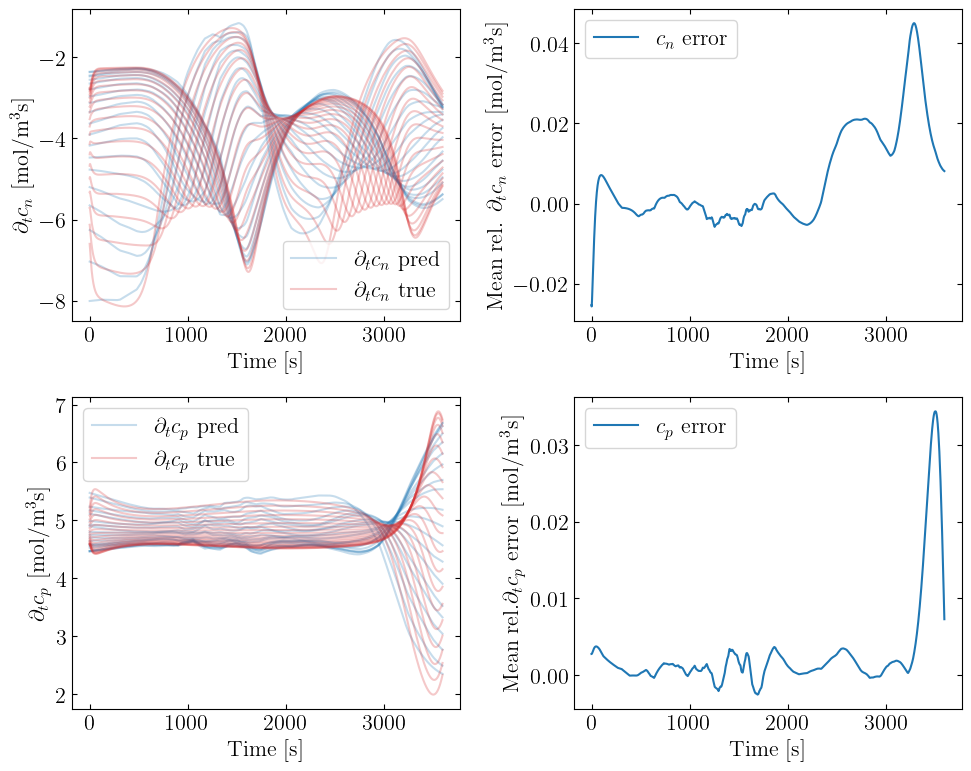

In [168]:
idx =0
dt = DT
cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run = rollout(idx=idx, on_train=False, dt = dt)
cn_traj = cn_traj[:steps_run]
cp_traj = cp_traj[:steps_run]
cn_dot_traj = cn_dot_traj[:steps_run]
cp_dot_traj = cp_dot_traj[:steps_run]
print(f"Rollout ran for {steps_run} steps (t={steps_run*dt:.2f}s)")
print("cn_traj shape:", cn_traj.shape)
print("cp_traj shape:", cp_traj.shape)
print("cn_dot_traj shape:", cn_dot_traj.shape)
print("cp_dot_traj shape:", cp_dot_traj.shape)
print("cn_dot_test shape:", cnr_dot_test[idx,:steps_run,0].shape)
f, ax = plt.subplots(2, 2, figsize=(10, 8))

t_preds = np.arange(len(cn_dot_traj[:steps_run])) * dt
t_true = np.arange(len(cnr_dot_test[idx, :steps_run, 0])) * dt

# ---- Row 1: c_n ----
ax[0, 0].plot(t_preds, cn_dot_traj[:steps_run, 1:], alpha=0.25, color='tab:blue')
ax[0, 0].plot(t_preds, cn_dot_traj[:steps_run, 0], alpha=0.25, color='tab:blue',
              label=r'$\partial_t c_n$ pred')
ax[0, 0].plot(t_true, cnr_dot_test[idx, :steps_run, 0], alpha=0.25, color='tab:red',
              label=r'$\partial_t c_n$ true')
ax[0, 0].plot(t_true, cnr_dot_test[idx, :steps_run, 1:], alpha=0.25, color='tab:red')
ax[0, 0].set_xlabel('Time [s]')
ax[0, 0].set_ylabel(r'$\partial_t c_n$ [mol/m$^3$s]')
ax[0, 0].legend()

ax[0, 1].plot(
    t_preds[:steps_run],
    np.mean((cn_dot_traj[:steps_run, :] - cnr_dot_test[idx, :steps_run, :]) / cnr_dot_test[idx, :steps_run, :], axis=1),
    label=r'$c_n$ error')
ax[0, 1].set_xlabel('Time [s]')
ax[0, 1].set_ylabel(r'Mean rel. $\partial_tc_n$ error [mol/m$^3$s]')
ax[0, 1].legend()


# ---- Row 2: c_p ----
ax[1, 0].plot(t_preds, cp_dot_traj[:steps_run, 1:], alpha=0.25, color='tab:blue')
ax[1, 0].plot(t_preds, cp_dot_traj[:steps_run, 0], alpha=0.25, color='tab:blue',
              label=r'$\partial_t c_p$ pred')
ax[1, 0].plot(t_true, cpr_dot_test[idx, :steps_run, 0], alpha=0.25, color='tab:red',
              label=r'$\partial_t c_p$ true')
ax[1, 0].plot(t_true, cpr_dot_test[idx, :steps_run, 1:], alpha=0.25, color='tab:red')
ax[1, 0].set_xlabel('Time [s]')
ax[1, 0].set_ylabel(r'$\partial_t c_p$ [mol/m$^3$s]')
ax[1, 0].legend()

ax[1, 1].plot(
    t_preds[:steps_run],
    np.mean((cp_dot_traj[:steps_run, :] - cpr_dot_test[idx, :steps_run, :])/cpr_dot_test[idx, :steps_run, :], axis=1),
    label=r'$c_p$ error'
)
ax[1, 1].set_xlabel('Time [s]')
ax[1, 1].set_ylabel(r'Mean rel.$\partial_tc_p$ error [mol/m$^3$s]')
ax[1, 1].legend()

plt.tight_layout()


plt.tight_layout()
#plt.plot(np.mean(cp_traj[:,:steps_run] - cpr_test[1,:steps_run,:], axis=1), label='cn error')
#plt.savefig(f'figs/cdot_rollout_i{idx}_{currents}.pdf', bbox_inches='tight')


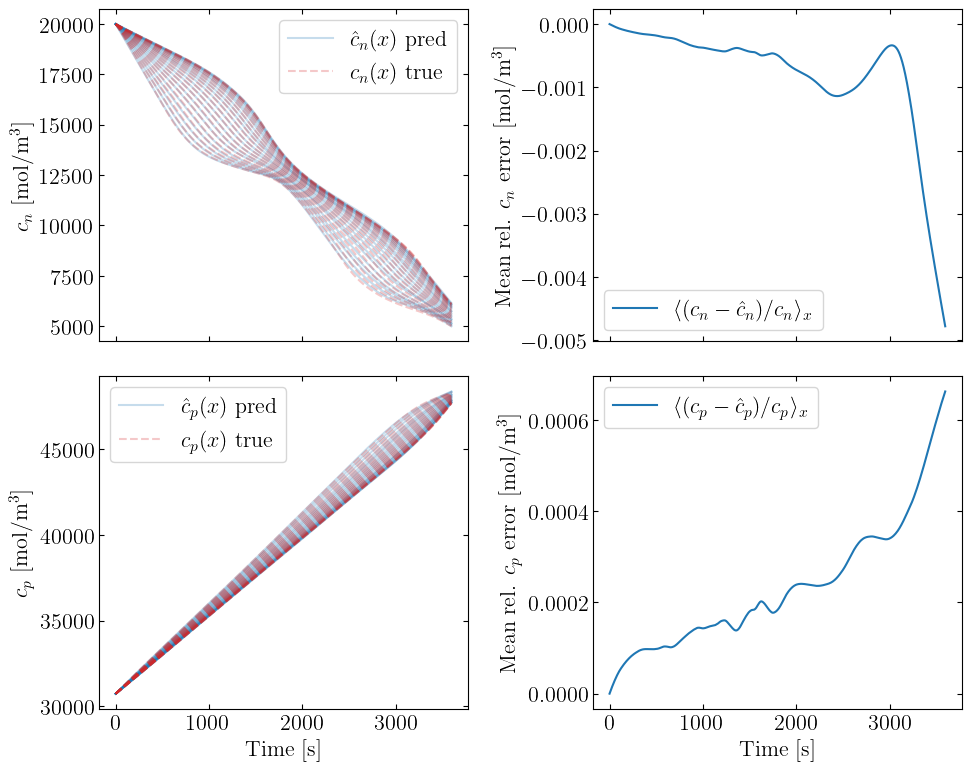

In [221]:
f, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)


# ---- Row 1: c_n ----


ax[0, 0].plot(t_preds, cn_traj[:steps_run, 1:], alpha=0.25, color='tab:blue')
ax[0, 0].plot(t_preds, cn_traj[:steps_run, 0], alpha=0.25, color='tab:blue',label=r'$\hat{c}_n(x)$ pred')
ax[0, 0].plot(t_true, cnr_test[idx, :steps_run, 0], alpha=0.25, color='tab:red',
              label=r'$c_n(x)$ true', linestyle='--')
ax[0, 0].plot(t_true, cnr_test[idx, :steps_run, 1:], alpha=0.25, color='tab:red',linestyle='--')
ax[0, 0].set_ylabel(r'$c_n$ [mol/m$^3$]')
ax[0, 0].legend()

ax[0, 1].plot(
    t_preds[:steps_run],
    np.mean((cn_traj[:steps_run, :] - cnr_test[idx, :steps_run, :]) / cnr_test[idx, :steps_run, :], axis=1),
    label=r'$\langle(c_n - \hat{c}_n)/c_n\rangle_x$')
ax[0, 1].set_ylabel(r'Mean rel. $c_n$ error [mol/m$^3$]')
ax[0, 1].legend()


# ---- Row 2: c_p ----

ax[1, 0].plot(t_preds, cp_traj[:steps_run, 1:], alpha=0.25, color='tab:blue')
ax[1, 0].plot(t_preds, cp_traj[:steps_run, 0], alpha=0.25, color='tab:blue',
              label=r'$\hat{c}_p(x)$ pred')
ax[1, 0].plot(t_true, cpr_test[idx, :steps_run, 0], alpha=0.25, color='tab:red',
              label=r'$c_p(x)$ true', linestyle='--')
ax[1, 0].plot(t_true, cpr_test[idx, :steps_run, 1:], alpha=0.25, color='tab:red', linestyle='--')
ax[1, 0].set_xlabel('Time [s]')
ax[1, 0].set_ylabel(r'$c_p$ [mol/m$^3$]')
ax[1, 0].legend()

ax[1, 1].plot(
    t_preds[:steps_run],
    np.mean((cp_traj[:steps_run, :] - cpr_test[idx, :steps_run, :])/cpr_test[idx, :steps_run, :], axis=1),
    label=r'$\langle(c_p - \hat{c}_p)/c_p\rangle_x$'
)
ax[1, 1].set_xlabel('Time [s]')
ax[1, 1].set_ylabel(r'Mean rel. $c_p$ error [mol/m$^3$]')
ax[1, 1].legend()

plt.tight_layout()
plt.savefig(f'figs/c_rollout_i{idx}_{currents}.pdf', bbox_inches='tight')

In [248]:
def calc_N(c,fv,L, A = params['Electrode height [m]'] * params['Electrode width [m]']):    
    dx = L / c.shape[1]  # node spacing
    Ns = np.sum(c, axis=1) * dx * fv * A
    return Ns

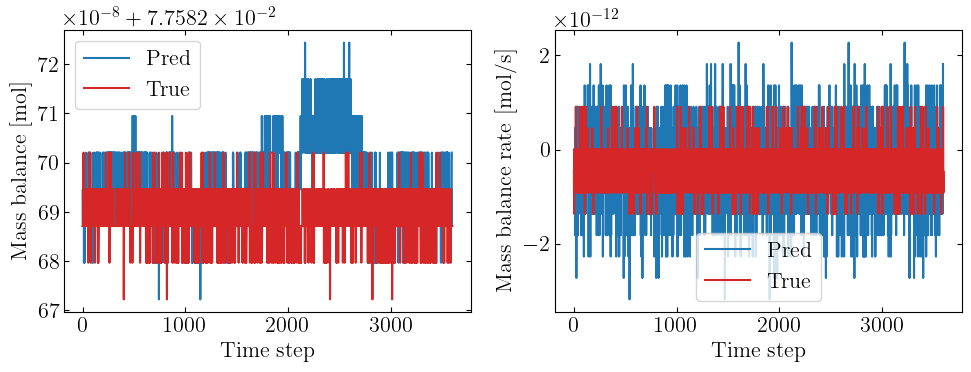

In [249]:
def test_mass_balance(cn_, cp_, params):
    # Example constraint: concentrations must be non-negative and below max
    vol_frac_n = params['Negative electrode active material volume fraction']
    vol_frac_p = params['Positive electrode active material volume fraction']
    epor_n = params['Negative electrode porosity']
    epor_p = params['Positive electrode porosity']

    Lp = params['Positive electrode thickness [m]']
    Ls = params['Separator thickness [m]']
    Ln = params['Negative electrode thickness [m]']

    conservation_diff = calc_N(cn_, vol_frac_n, Ln) + calc_N(cp_, vol_frac_p, Lp)
    #conservation_diff = np.round(conservation_diff, decimals=7)  # Round to avoid tiny numerical errors
    return conservation_diff
f,ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(test_mass_balance(cn_traj, cp_traj, params), label='Pred', color = 'tab:blue')
ax[0].plot(test_mass_balance(cnr_test[idx], cpr_test[idx], params), label='True', color = 'tab:red')
ax[1].plot(test_mass_balance(cn_dot_traj, cp_dot_traj, params), label='Pred',color = 'tab:blue')
ax[1].plot(test_mass_balance(cnr_dot_test[idx], cpr_dot_test[idx], params), label='True', color = 'tab:red')
ax[0].set_ylabel('Mass balance [mol]')
ax[1].set_ylabel('Mass balance rate [mol/s]')
for a in ax:
    a.set_xlabel('Time step')
    a.legend()
plt.tight_layout()

#plt.savefig(f'figs/PE_mass_balance_i{idx}_{currents}.pdf', bbox_inches='tight')

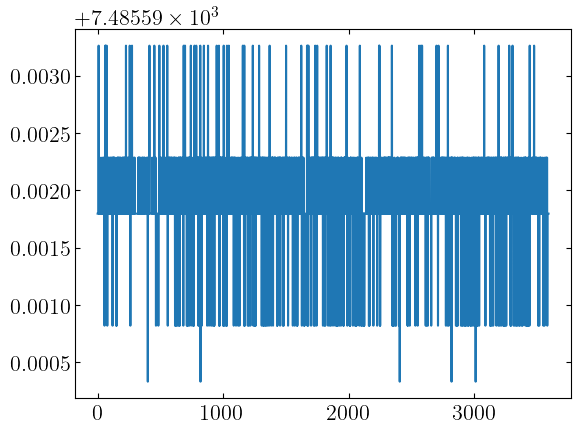

In [254]:
import scipy.constants as sc
F = sc.physical_constants['Faraday constant'][0]  # C/mol
plt.plot(test_mass_balance(cnr_test[idx, :steps_run,:], cpr_test[idx,:steps_run,:], params) * F)



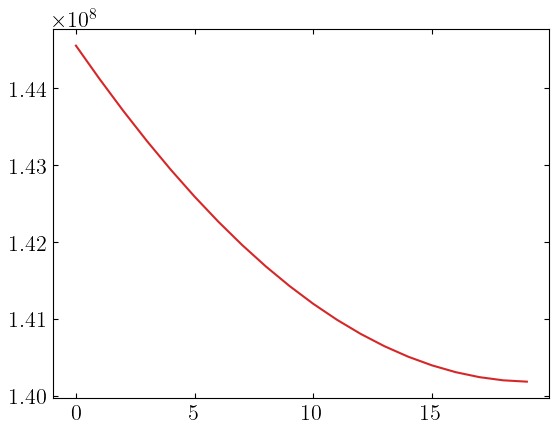

In [172]:
plt.plot(cpr_test[idx,:,:].sum(axis=0), label='cn total true', color = 'tab:red')

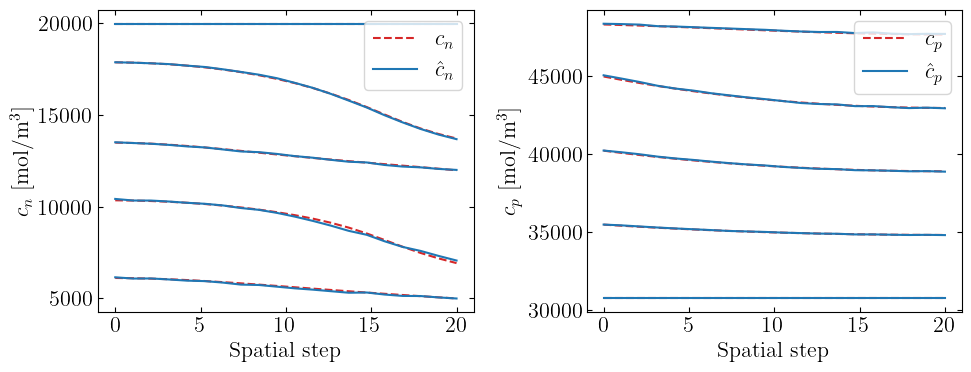

In [224]:
def test_mononicity(cn_, cp_):
    '''Concentration should secrease as a function of x in the negative electrode and increase in the positive electrode'''
    cn_diff = np.sum(cn_,axis=0)  # (T, R-1)
    cp_diff = np.sum(cp_,axis=0)  # (T, R-1)
    return cn_diff, cp_diff

cn_diff_pred, cp_diff_pred = test_mononicity(cn_dot_traj, cp_dot_traj)
cn_diff_true, cp_diff_true = test_mononicity(cnr_dot_test[idx], cpr_dot_test[idx])
f, ax = plt.subplots(1, 2, figsize=(10, 4))
#ax[0].plot(cn_diff_pred, label='cn diff pred', color = 'tab:blue')
for times in np.linspace(0, len(t_preds)-1, 5):
    if times == 0:
        ax[0].plot(np.linspace(0,cnr_test.shape[-1],cnr_dot_test.shape[-1]),cnr_test[idx,int(times),:],color = 'tab:red', linestyle='dashed', label = r'$c_n$')
        ax[0].plot(np.linspace(0,cn_traj.shape[1],cn_dot_traj.shape[1]),cn_traj[int(times),:],color = 'tab:blue', label = r'$\hat{c}_n$')
        ax[1].plot(np.linspace(0,cpr_test.shape[-1],cpr_test.shape[-1]),cpr_test[idx,int(times),:],color = 'tab:red',  linestyle='dashed', label = r'$c_p$')
        ax[1].plot(np.linspace(0,cp_traj.shape[1],cp_dot_traj.shape[1]),cp_traj[int(times),:],color = 'tab:blue', label = r'$\hat{c}_p$')
    else:
        ax[0].plot(np.linspace(0,cnr_test.shape[-1],cnr_dot_test.shape[-1]),cnr_test[idx,int(times),:],color = 'tab:red', linestyle='dashed')
        ax[0].plot(np.linspace(0,cn_traj.shape[1],cn_dot_traj.shape[1]),cn_traj[int(times),:],color = 'tab:blue')
        ax[1].plot(np.linspace(0,cpr_test.shape[-1],cpr_test.shape[-1]),cpr_test[idx,int(times),:],color = 'tab:red',  linestyle='dashed')
        ax[1].plot(np.linspace(0,cp_traj.shape[1],cp_dot_traj.shape[1]),cp_traj[int(times),:],color = 'tab:blue')
#ax[0].plot(cn_diff_true, label='cn diff true', color = 'tab:red')
#ax[1].plot(cp_diff_pred, label='cp diff pred', color = 'tab:blue')
#ax[1].plot(cp_diff_true, label='cp diff true', color = 'tab:red')
ax[0].set_ylabel('$c_n$ [mol/m$^3$]')
ax[1].set_ylabel('$c_p$ [mol/m$^3$]')
ax[0].set_xlabel('Spatial step')
ax[1].set_xlabel('Spatial step')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.savefig(f'figs/PE_results_i{idx}_{currents}.pdf', bbox_inches='tight')
